In [1]:
##INSTALL REQUIRED LIBRARIES

import subprocess
import sys

packages = [
    'scikit-learn',
    'plotly',
    'ipywidgets',
    'rapidfuzz',
    'scipy',
    'seaborn',
    'matplotlib'
]

for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])
        print(f"{pkg} installed successfully.")

print('\nAll libraries ready!')



Installing scikit-learn...
scikit-learn installed successfully.
Installing rapidfuzz...
rapidfuzz installed successfully.

All libraries ready!


In [2]:

##IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from ipywidgets import (
    interact, interactive, fixed, interact_manual,
    widgets, HBox, VBox, Layout, Tab, Output, HTML
    )
from IPython.display import display, clear_output, HTML as IPHTML
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from rapidfuzz import fuzz, process
import json
import warnings
import re
from collections import Counter, defaultdict
import itertools

warnings.filterwarnings('ignore')

# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Plotly dark theme template
DARK_TEMPLATE = 'plotly_dark'

print('Libraries imported successfully!')



Libraries imported successfully!


In [3]:

# CELL 3: LOAD DATA

datasource = "https://docs.google.com/spreadsheets/d/1z42wksx6-AAyT_l04sRu9UeHv8DZJRpWUuK-WtSPV50/export?format=csv"


# For local or pre-uploaded file:
df = pd.read_csv(datasource)

# Create a working copy - NEVER modify original data
df_original = df.copy()

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")


Dataset loaded: 1504 rows × 27 columns

Columns: ['sl', 'name', 'country', 'region', 'size', 'focus', 'research', 'status', 'AR SCORE', 'AR RANK', 'ER SCORE', 'ER RANK', 'FSR SCORE', 'FSR RANK', 'CPF SCORE', 'CPF RANK', 'IFR SCORE', 'IFR RANK', 'ISR SCORE', 'ISR RANK', 'IRN SCORE', 'IRN RANK', 'EO SCORE', 'EO RANK', 'SUS SCORE', 'SUS RANK', 'Overall SCORE']


## Missing Value

In [4]:

# 1.1 MISSING VALUE ANALYSIS


def analyze_missing_values(df):
    """Comprehensive missing value analysis"""
    results = {}
    total_rows = len(df)

    for col in df.columns:
        nan_count = df[col].isna().sum()
        dash_count = (df[col] == '-').sum() if df[col].dtype == object else 0
        empty_count = (df[col] == '').sum() if df[col].dtype == object else 0

        # Special character patterns (701+, 801+, 43=, etc.)
        special_count = 0
        special_patterns = []
        if df[col].dtype == object:
            for val in df[col].dropna().astype(str):
                if re.search(r'\d+[+=]', val):
                    special_count += 1
                    special_patterns.append(val)

        total_missing = nan_count + dash_count + empty_count + special_count

        results[col] = {
            'NaN': nan_count,
            "'-'": dash_count,
            'Empty': empty_count,
            'Special (701+, 801+, etc.)': special_count,
            'Total Missing': total_missing,
            'Missing %': round(total_missing / total_rows * 100, 2),
            'Special Patterns': list(set(special_patterns))[:5]
        }

    return pd.DataFrame(results).T

missing_analysis = analyze_missing_values(df)
print("=== MISSING VALUE ANALYSIS ===")
print(missing_analysis[['NaN', "'-'", 'Empty', 'Special (701+, 801+, etc.)', 'Total Missing', 'Missing %']].to_string())

=== MISSING VALUE ANALYSIS ===
              NaN  '-' Empty Special (701+, 801+, etc.) Total Missing Missing %
sl              0    0     0                          0             0       0.0
name            0    0     0                          0             0       0.0
country         0    0     0                          0             0       0.0
region          0    0     0                          0             0       0.0
size            5    0     0                          0             5      0.33
focus           1    0     0                          0             1      0.07
research        7    0     0                          0             7      0.47
status         56    0     0                          0            56      3.72
AR SCORE        0    0     0                          0             0       0.0
AR RANK         0    0     0                        804           804     53.46
ER SCORE        0    0     0                          0             0       0.0
ER RANK  

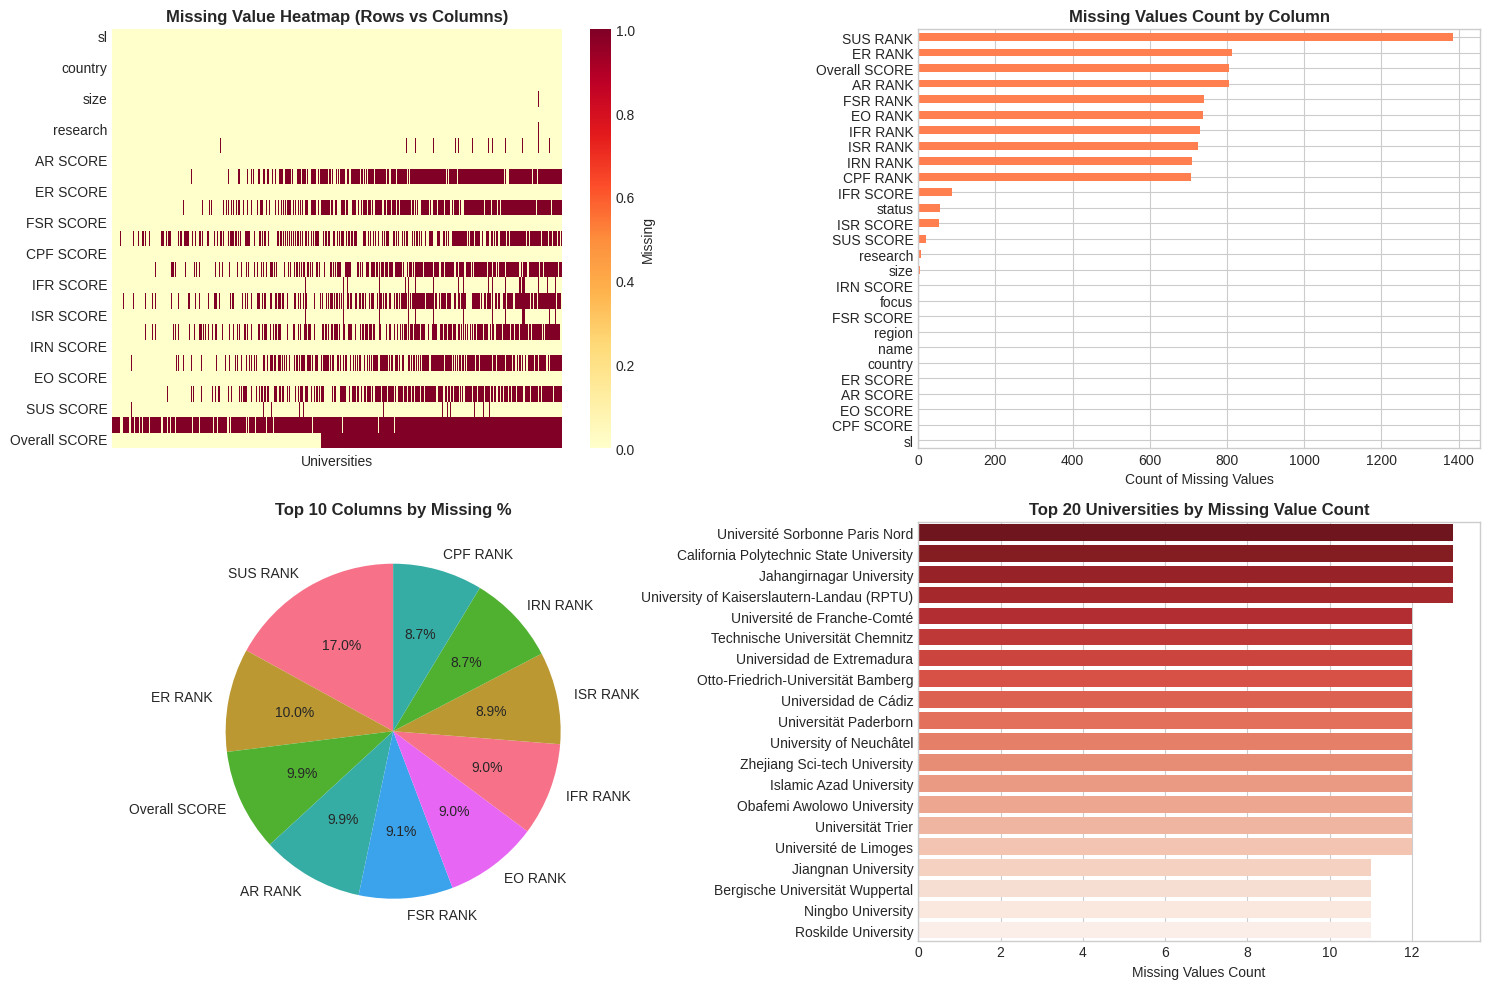


=== MISSING VALUE SUMMARY ===
Total universities: 1504
Universities with missing Overall SCORE: 804
Universities with missing status: 56
Universities with missing size: 5


In [5]:
# ============================================================
# MISSING VALUE VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # Create a 2x2 grid of subplots

# 1. Missing value heatmap
ax1 = axes[0, 0]
missing_matrix = df.isnull().astype(int) + (df == '-').astype(int)
for col in df.columns:
    if df[col].dtype == object:
        missing_matrix[col] += df[col].astype(str).str.contains(r'\d+[+=]', na=False).astype(int)
sns.heatmap(missing_matrix.T, cmap='YlOrRd', cbar_kws={'label': 'Missing'}, ax=ax1, xticklabels=False)
ax1.set_title('Missing Value Heatmap (Rows vs Columns)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Universities')

# 2. Missing value bar chart by column
ax2 = axes[0, 1]
missing_counts = missing_analysis['Total Missing'].sort_values(ascending=True)
missing_counts.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Missing Values Count by Column', fontsize=12, fontweight='bold')
ax2.set_xlabel('Count of Missing Values')

# 3. Missing value percentage pie chart (top columns)
ax3 = axes[1, 0]
top_missing = missing_analysis[missing_analysis['Total Missing'] > 0]['Missing %'].sort_values(ascending=False).head(10)
ax3.pie(top_missing.values, labels=top_missing.index, autopct='%1.1f%%', startangle=90)
ax3.set_title('Top 10 Columns by Missing %', fontsize=12, fontweight='bold')

# --- FIX: Calculate missing values per university to define df_temp ---
def count_missing_row(row):
    nan_count = row.isna().sum()
    dash_count = (row == '-').sum() if row.dtype == object else 0
    special_count = 0
    for val in row.dropna().astype(str):
        if re.search(r'\d+[+=]', val):
            special_count += 1
    return nan_count + dash_count + special_count

df_temp = pd.DataFrame({
    'name': df['name'],
    'missing_count': df.apply(count_missing_row, axis=1)
})
# -----------------------------------------------------------

# 4. Missing values per university (top 20)
ax4 = axes[1, 1]
top_missing_unis = df_temp.nlargest(20, 'missing_count')
sns.barplot(data=top_missing_unis, y='name', x='missing_count', ax=ax4, palette='Reds_r')
ax4.set_title('Top 20 Universities by Missing Value Count', fontsize=12, fontweight='bold')
ax4.set_xlabel('Missing Values Count')
ax4.set_ylabel('')

plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== MISSING VALUE SUMMARY ===")
print(f"Total universities: {len(df)}")
print(f"Universities with missing Overall SCORE: {(df['Overall SCORE'] == '-').sum()}")
print(f"Universities with missing status: {df['status'].isna().sum() + (df['status'] == '-').sum()}")
print(f"Universities with missing size: {df['size'].isna().sum() + (df['size'] == '-').sum()}")

In [6]:

# ============================================================
# PHASE 1.2 - DATA TYPE CONVERSION & CLEANING
# ============================================================

# Define column groups
SCORE_COLS = ['AR SCORE', 'ER SCORE', 'FSR SCORE', 'CPF SCORE',
              'IFR SCORE', 'ISR SCORE', 'IRN SCORE', 'EO SCORE', 'SUS SCORE']
RANK_COLS = ['AR RANK', 'ER RANK', 'FSR RANK', 'CPF RANK',
             'IFR RANK', 'ISR RANK', 'IRN RANK', 'EO RANK', 'SUS RANK']
INDICATORS = ['AR', 'ER', 'FSR', 'CPF', 'IFR', 'ISR', 'IRN', 'EO', 'SUS']

# Clean and convert score columns
def clean_score(val):
    """Convert score values to numeric, treating '-' and '701+' patterns as NaN"""
    if pd.isna(val) or val == '-' or val == '':
        return np.nan
    val_str = str(val).strip()
    # Handle patterns like "701+", "801+", "43=" in score columns
    if re.search(r'\d+[+=]', val_str):
        return np.nan
    try:
        return float(val_str)
    except ValueError:
        return np.nan

# Clean and convert rank columns
def clean_rank(val):
    """Parse rank values: '701+' -> 701, '43=' -> 43, '-' -> NaN"""
    if pd.isna(val) or val == '-' or val == '':
        return np.nan
    val_str = str(val).strip()
    # Extract numeric part from patterns like "701+", "43="
    match = re.match(r'(\d+)[+=]?', val_str)
    if match:
        return int(match.group(1))
    try:
        return int(float(val_str))
    except ValueError:
        return np.nan

# Create cleaned numeric versions (stored in new columns, original preserved)
for col in SCORE_COLS:
    new_col = col.replace('SCORE', 'score_clean')
    df[new_col] = df[col].apply(clean_score)

for col in RANK_COLS:
    new_col = col.replace('RANK', 'rank_clean')
    df[new_col] = df[col].apply(clean_rank)

# Clean Overall SCORE
df['overall_score_clean'] = df['Overall SCORE'].apply(clean_score)

print("=== DATA TYPE CONVERSION COMPLETE ===")
print(f"Score columns cleaned and stored as '*_score_clean'")
print(f"Rank columns parsed and stored as '*_rank_clean'")
print(f"\nCleaned score columns sample:")
sample = (df[['name'] + [c.replace('SCORE', 'score_clean') for c in SCORE_COLS]])
print(sample.head().to_string())

print(f"\nCleaned rank columns sample:")
sample = (df[['name'] + [c.replace('RANK', 'rank_clean') for c in RANK_COLS]])
print(sample.head().to_string())

=== DATA TYPE CONVERSION COMPLETE ===
Score columns cleaned and stored as '*_score_clean'
Rank columns parsed and stored as '*_rank_clean'

Cleaned score columns sample:
                                          name  AR score_clean  ER score_clean  FSR score_clean  CPF score_clean  IFR score_clean  ISR score_clean  IRN score_clean  EO score_clean  SUS score_clean
0  Massachusetts Institute of Technology (MIT)           100.0           100.0            100.0            100.0            100.0             91.1             94.4           100.0             93.2
1                      Imperial College London            99.6           100.0             98.9             93.8            100.0            100.0             98.8            96.4             98.0
2                          Stanford University           100.0           100.0            100.0             98.8             97.9             75.1             96.8           100.0             97.6
3                         University of Ox

In [7]:
 #PHASE 2.2 (MOVED EARLIER) - STATUS & SIZE MANUAL ENTRY SECTION
# Runs before imputation now, because Layer 1/2 imputation below
# groups by (country, size, research) and encodes status — both
# must be complete first, or the grouping/encoding is wrong.
# ============================================================

missing_status = df[(df['status'].isna()) | (df['status'] == '-') | (df['status'] == '')]
missing_size   = df[(df['size'].isna())   | (df['size'] == '-')   | (df['size'] == '')]

print("=" * 80)
print("MANUAL ENTRY: STATUS & SIZE")
print("=" * 80)
print(f"\nUniversities with MISSING STATUS before fill: {len(missing_status)}")
print(f"Universities with MISSING SIZE before fill:   {len(missing_size)}")

status_updates = {
    79: "Public", 97: "Public", 363: "Public", 516: "Public", 648: "Public",
    668: "Public", 810: "Public", 846: "Private not for Profit", 867: "Public",
    897: "Public", 941: "Public", 967: "Public", 985: "Public", 1008: "Public",
    1015: "Public", 1020: "Public", 1023: "Private not for Profit", 1030: "Public",
    1076: "Public", 1093: "Public", 1110: "Public", 1123: "Public", 1125: "Public",
    1130: "Public", 1145: "Public", 1149: "Public", 1159: "Public", 1160: "Public",
    1184: "Public", 1206: "Public", 1225: "Public", 1237: "Public", 1260: "Public",
    1269: "Public", 1273: "Public", 1274: "Public", 1317: "Public", 1318: "Public",
    1331: "Public", 1335: "Public", 1341: "Public", 1342: "Public", 1344: "Public",
    1345: "Public", 1346: "Public", 1373: "Public", 1382: "Public", 1388: "Public",
    1391: "Public", 1392: "Public", 1402: "Public", 1427: "Private not for Profit",
    1443: "Public", 1464: "Public", 1483: "Public", 1488: "Public"
}

for sl_val, status_val in status_updates.items():
    mask = df['sl'] == sl_val
    if mask.sum() > 0:
        df.loc[mask, 'status'] = status_val
    else:
        print(f"  ⚠️  sl={sl_val} not found in dataset — skipped")

print(f"\n✅ Applied {len(status_updates)} status updates.")

size_updates = {
    987: 'L',
    1409: 'L',
    1427: 'XL',
    1429: 'L',
    1490: 'L'
}

for sl_val, size_val in size_updates.items():
    mask = df['sl'] == sl_val
    if mask.sum() > 0:
        df.loc[mask, 'size'] = size_val
    else:
        print(f"  ⚠️  sl={sl_val} not found in dataset — skipped")

print(f"✅ Applied {len(size_updates)} size updates.")

remaining_status = df[(df['status'].isna()) | (df['status'] == '-') | (df['status'] == '')]
remaining_size   = df[(df['size'].isna())   | (df['size'] == '-')   | (df['size'] == '')]

print("\n" + "=" * 80)

if len(remaining_status) > 0 or len(remaining_size) > 0:
    print("⚠️  VALIDATION FAILED — Gaps still remain!")

    if len(remaining_status) > 0:
        print(f"\n--- Still missing STATUS ({len(remaining_status)} universities) ---")
        print(remaining_status[['sl', 'name', 'country', 'status']].to_string(index=False))

    if len(remaining_size) > 0:
        print(f"\n--- Still missing SIZE ({len(remaining_size)} universities) ---")
        print(remaining_size[['sl', 'name', 'country', 'size']].to_string(index=False))

    print("\n🛑 NOTEBOOK HALTED. Please add the missing values above, then re-run this cell.")
    raise SystemExit("Manual entry incomplete: status/size still have gaps.")
else:
    print("✅ VALIDATION PASSED — All status and size values are filled.")
    print(f"   Total universities: {len(df)}")
    print(f"   Status distribution:\n{df['status'].value_counts().to_string()}")
    print(f"\n   Size distribution:\n{df['size'].value_counts().to_string()}")




MANUAL ENTRY: STATUS & SIZE

Universities with MISSING STATUS before fill: 56
Universities with MISSING SIZE before fill:   5

✅ Applied 56 status updates.
✅ Applied 5 size updates.

✅ VALIDATION PASSED — All status and size values are filled.
   Total universities: 1504
   Status distribution:
status
Public                    1197
Private not for Profit     255
Private for Profit          52

   Size distribution:
size
L     656
M     378
XL    365
S     105


In [8]:
# PHASE 2.1 (FIXED) - 3-LAYER SCORE IMPUTATION
# Layer 1: group median by (country, size, research), min group n=3
# Layer 2: KNN using size + status + research + scores
#          (country dropped from KNN features -- see note below)
# Layer 3: global median safety net


score_clean_cols = [c.replace('SCORE', 'score_clean') for c in SCORE_COLS]

# Start imputed columns as a copy of the cleaned scores
for col in score_clean_cols:
    df[col.replace('score_clean', 'score_imputed')] = df[col]
imputed_cols = [c.replace('score_clean', 'score_imputed') for c in score_clean_cols]

print("Before imputation - missing scores per indicator:")
for col in score_clean_cols:
    print(f"  {col}: {df[col].isna().sum()} missing")

# --- LAYER 1: group median by (country, size, research) ---
group_cols = ['country', 'size', 'research']
layer1_filled = 0
for col, imp_col in zip(score_clean_cols, imputed_cols):
    group_median = df.groupby(group_cols)[col].transform(
        lambda s: s.median() if s.notna().sum() >= 3 else np.nan
    )
    mask = df[imp_col].isna() & group_median.notna()
    df.loc[mask, imp_col] = group_median[mask]
    layer1_filled += mask.sum()

print(f"\nLayer 1 (group median by country+size+research, min group n=3): filled {layer1_filled} values")
for col in imputed_cols:
    print(f"  {col}: {df[col].isna().sum()} still missing")

# --- LAYER 2: KNN using size + status + research + scores ---
# FIX: 'country' used to be run through LabelEncoder into an arbitrary
# integer (e.g. Bangladesh=12, France=13, alphabetical order) and fed
# straight into KNN's Euclidean distance. That makes numerically adjacent
# countries look "similar" to KNN even though the encoding is meaningless,
# which can pull in the wrong neighbors when imputing missing scores.
# Country-level signal is already captured properly in Layer 1 (grouped by
# the real country name, not an encoded number), so we drop it here rather
# than one-hot encoding 100+ countries and diluting the more informative
# size/status/research/score features in the distance calculation.
size_order = {'S': 0, 'M': 1, 'L': 2, 'XL': 3}
research_order = {'LO': 0, 'MD': 1, 'HI': 2, 'VH': 3}
df['size_encoded'] = df['size'].map(size_order)
df['research_encoded'] = df['research'].map(research_order)
le_status = LabelEncoder()
df['status_encoded'] = le_status.fit_transform(df['status'].astype(str))

knn_features = ['size_encoded', 'status_encoded', 'research_encoded'] + imputed_cols
impute_df = df[knn_features].copy()

still_missing_mask = df[imputed_cols].isna().any(axis=1)
print(f"\nLayer 2 candidates (still missing at least 1 indicator): {still_missing_mask.sum()} rows")

if still_missing_mask.sum() > 0:
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    imputed_array = knn_imputer.fit_transform(impute_df)
    n_meta = 3  # size/status/research encoded cols come first
    for i, col in enumerate(imputed_cols):
        vals = imputed_array[:, n_meta + i]
        mask = df[col].isna()
        df.loc[mask, col] = vals[mask.values]

print("Remaining missing after Layer 2 (KNN):")
for col in imputed_cols:
    print(f"  {col}: {df[col].isna().sum()}")

# --- LAYER 3: global median safety net ---
layer3_filled = 0
for col in imputed_cols:
    mask = df[col].isna()
    if mask.sum() > 0:
        df.loc[mask, col] = df[col].median()
        layer3_filled += mask.sum()
print(f"\nLayer 3 (global median safety net): filled {layer3_filled} values")

print(f"\n=== IMPUTATION COMPLETE ===")
for col in imputed_cols:
    missing = df[col].isna().sum()
    print(f"  {col}: {missing} missing (should be 0)")

#comparison graph
import matplotlib.pyplot as plt
import numpy as np


Before imputation - missing scores per indicator:
  AR score_clean: 0 missing
  ER score_clean: 0 missing
  FSR score_clean: 1 missing
  CPF score_clean: 0 missing
  IFR score_clean: 87 missing
  ISR score_clean: 55 missing
  IRN score_clean: 2 missing
  EO score_clean: 0 missing
  SUS score_clean: 20 missing

Layer 1 (group median by country+size+research, min group n=3): filled 84 values
  AR score_imputed: 0 still missing
  ER score_imputed: 0 still missing
  FSR score_imputed: 1 still missing
  CPF score_imputed: 0 still missing
  IFR score_imputed: 37 still missing
  ISR score_imputed: 29 still missing
  IRN score_imputed: 2 still missing
  EO score_imputed: 0 still missing
  SUS score_imputed: 12 still missing

Layer 2 candidates (still missing at least 1 indicator): 51 rows
Remaining missing after Layer 2 (KNN):
  AR score_imputed: 0
  ER score_imputed: 0
  FSR score_imputed: 0
  CPF score_imputed: 0
  IFR score_imputed: 0
  ISR score_imputed: 0
  IRN score_imputed: 0
  EO score

In [9]:
# CELL 8: PHASE 2.2 - CALCULATE NEW OVERALL SCORE
# ============================================================

# QS weights for 9 indicators (standard QS methodology)
# AR: Academic Reputation (30%), ER: Employer Reputation (15%),
# FSR: Faculty Student Ratio (10%), CPF: Citations per Faculty (20%)
# IFR: International Faculty Ratio (5%), ISR: International Student Ratio (5%)
# IRN: International Research Network (5%), EO: Employment Outcomes (5%)
# SUS: Sustainability (5%)

QS_WEIGHTS = {
    'AR': 0.30,
    'ER': 0.15,
    'FSR': 0.10,
    'CPF': 0.20,
    'IFR': 0.05,
    'ISR': 0.05,
    'IRN': 0.05,
    'EO': 0.05,
    'SUS': 0.05
}

# --- FIX: standardize each indicator before weighting ---
# Previously the raw 0-100 imputed scores were weighted and summed directly.
# Indicators with a wider spread across universities (e.g. CPF) then swung
# the overall score more than their stated weight implied, while narrow-
# spread indicators swung it less -- QS's own methodology avoids this by
# Z-scoring each indicator first. We Z-score each indicator, then rescale
# that Z-score back onto a 0-100 range (so 'overall_score_new' stays
# comparable to the original 0-100 'Overall SCORE' column used later in the
# comparison report), and only then apply the weights.
standardized_cols = []
for indicator in INDICATORS:
    raw_col = f"{indicator} score_imputed"
    std_col = f"{indicator} score_standardized"
    z = (df[raw_col] - df[raw_col].mean()) / df[raw_col].std()
    z_range = z.max() - z.min()
    df[std_col] = (z - z.min()) / z_range * 100 if z_range > 0 else 50.0
    standardized_cols.append(std_col)

# Calculate weighted overall score using standardized values
weighted_sum = np.zeros(len(df))
for indicator in INDICATORS:
    col_name = f"{indicator} score_standardized"
    weighted_sum += df[col_name] * QS_WEIGHTS[indicator]

df['overall_score_new'] = weighted_sum

print("=== NEW OVERALL SCORE CALCULATED (standardized indicators) ===")
print(f"Using QS standard weights: {QS_WEIGHTS}")
print(f"\nSample comparison (Original vs New):")
comparison = df[['name', 'Overall SCORE', 'overall_score_new']].head(10)
print(comparison.to_string())

print(f"\nStatistics for overall_score_new:")
print(df['overall_score_new'].describe())


=== NEW OVERALL SCORE CALCULATED (standardized indicators) ===
Using QS standard weights: {'AR': 0.3, 'ER': 0.15, 'FSR': 0.1, 'CPF': 0.2, 'IFR': 0.05, 'ISR': 0.05, 'IRN': 0.05, 'EO': 0.05, 'SUS': 0.05}

Sample comparison (Original vs New):
                                           name Overall SCORE  overall_score_new
0   Massachusetts Institute of Technology (MIT)           100          98.916437
1                       Imperial College London          99.2          98.169421
2                           Stanford University          99.2          98.108356
3                          University of Oxford          98.6          97.507117
4                            Harvard University          97.4          96.396235
5                       University of Cambridge          97.1          96.059458
6  California Institute of Technology (Caltech)          96.6          95.523735
7                                    ETH Zurich          96.3          95.257861
8                              

In [10]:
# PHASE 2.3 - CALCULATE NEW DENSE RANKS
# ============================================================

# Calculate dense ranks for each indicator based on imputed scores
# Dense rank: 1, 2, 2, 3 (no gaps between tied ranks) -- fine for per-indicator ranks
# Note: this ranks on the raw imputed scores (score_imputed), not the
# standardized versions -- rank order within an indicator is identical
# either way, since standardization is a strictly increasing transform
# applied per column and can't reorder universities on that indicator.

for indicator in INDICATORS:
    score_col = f"{indicator} score_imputed"
    rank_col = f"{indicator}_rank_new"
    # Dense rank: higher score = better rank (rank 1 = highest)
    df[rank_col] = df[score_col].rank(method='dense', ascending=False).astype(int)


tiebreak_cols = ['overall_score_new'] + [f"{ind} score_standardized" for ind in INDICATORS]
_sort_df = df[['sl'] + tiebreak_cols + ['name']].sort_values(
    by=tiebreak_cols + ['name'],
    ascending=[False] * len(tiebreak_cols) + [True]
).reset_index(drop=True)
_sort_df['overall_rank_new'] = np.arange(1, len(_sort_df) + 1)
df = df.merge(_sort_df[['sl', 'overall_rank_new']], on='sl', how='left')

print("=== NEW DENSE RANKS CALCULATED ===")
print(f"New rank columns created: '*_rank_new' and 'overall_rank_new'")
print(f"\nTop 10 universities by new overall rank:")
top10 = df.nsmallest(10, 'overall_rank_new')[['name', 'country', 'overall_score_new', 'overall_rank_new']]
print(top10.to_string(index=False))

print(f"\nNew rank distribution:")
for indicator in INDICATORS:
    rank_col = f"{indicator}_rank_new"
    print(f"  {rank_col}: min={df[rank_col].min()}, max={df[rank_col].max()}, unique={df[rank_col].nunique()}")


=== NEW DENSE RANKS CALCULATED ===
New rank columns created: '*_rank_new' and 'overall_rank_new'

Top 10 universities by new overall rank:
                                        name                  country  overall_score_new  overall_rank_new
 Massachusetts Institute of Technology (MIT) United States of America          98.916437                 1
                     Imperial College London           United Kingdom          98.169421                 2
                         Stanford University United States of America          98.108356                 3
                        University of Oxford           United Kingdom          97.507117                 4
                          Harvard University United States of America          96.396235                 5
                     University of Cambridge           United Kingdom          96.059458                 6
California Institute of Technology (Caltech) United States of America          95.523735                 7
     

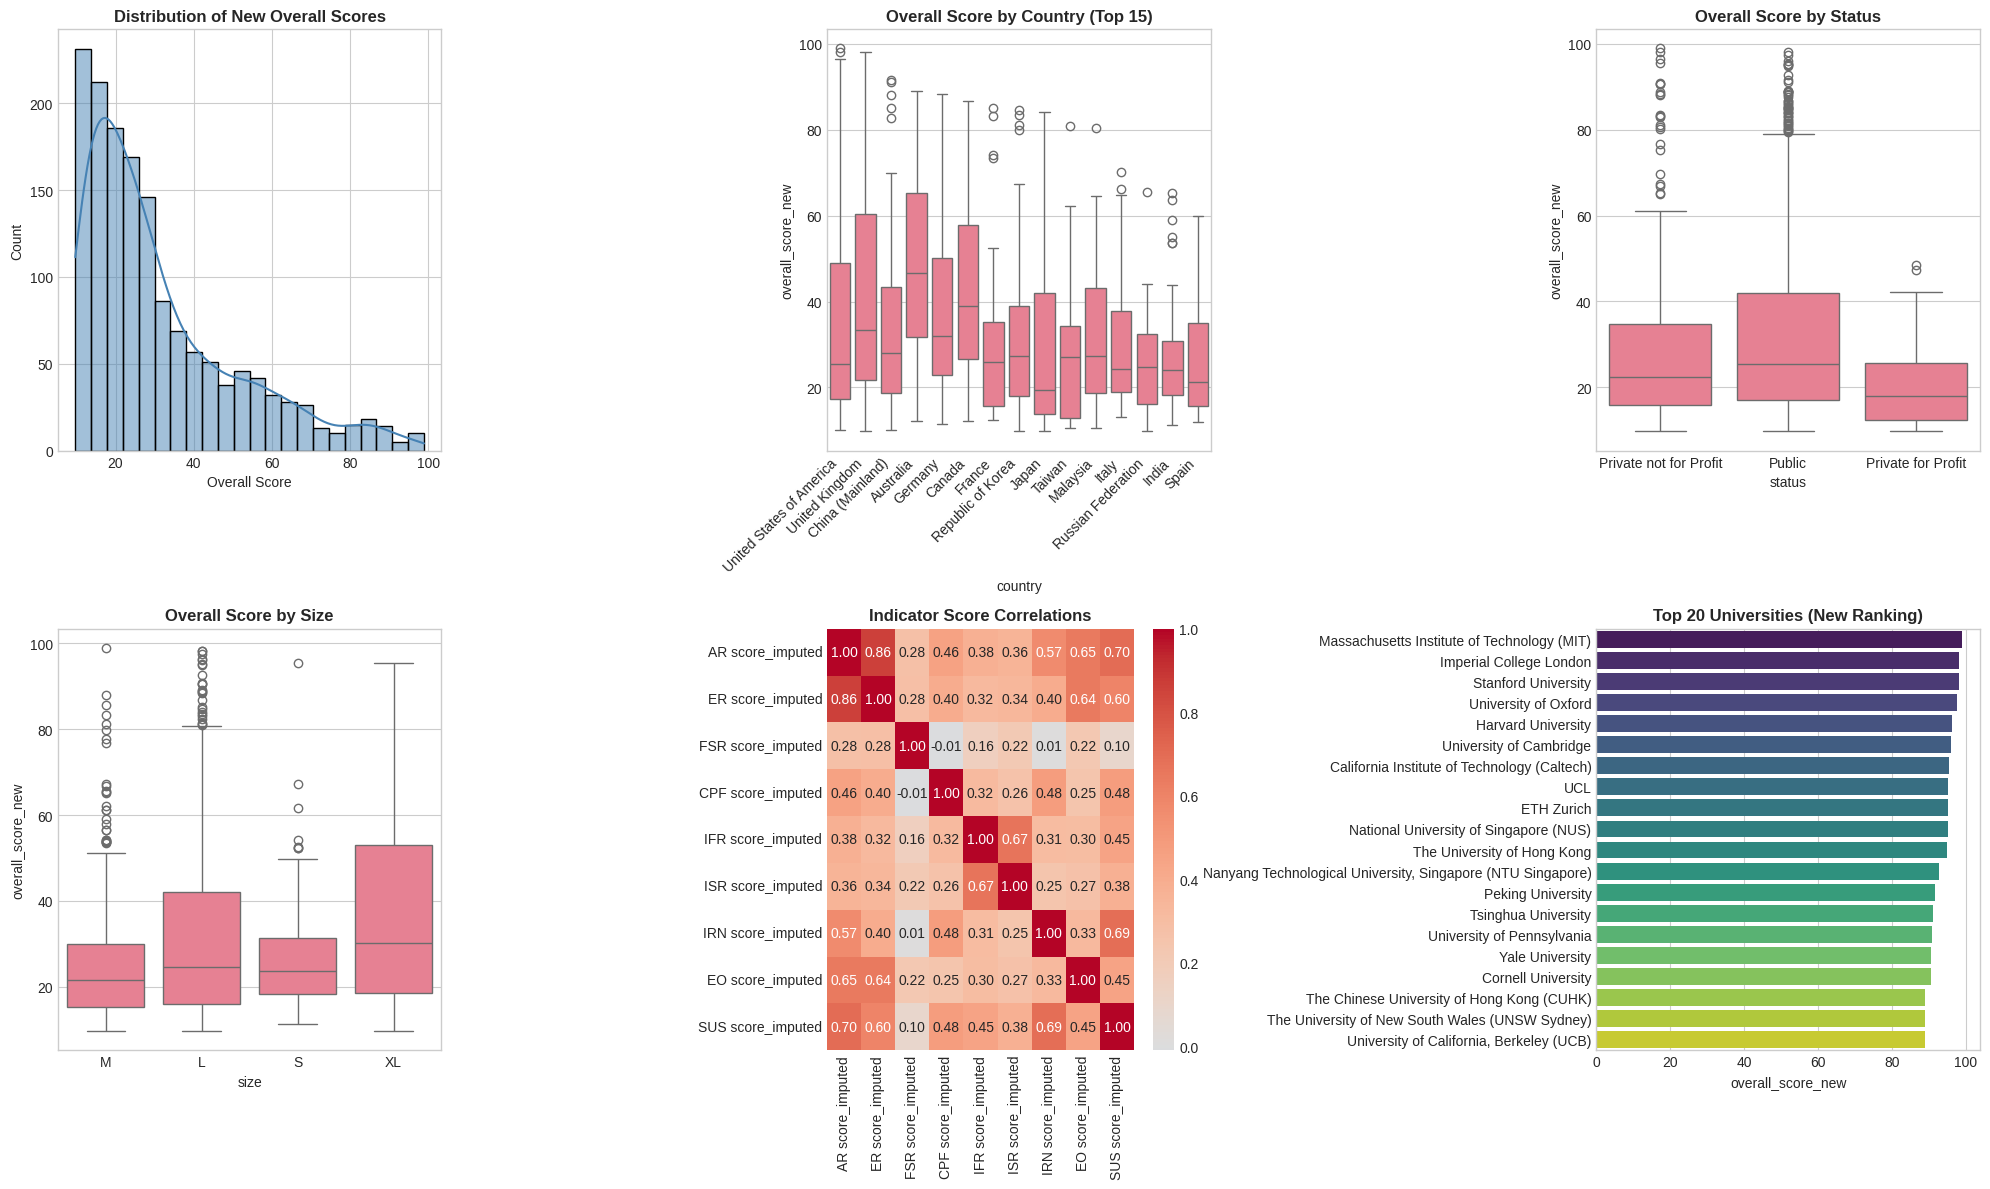

In [11]:
#============================================================
# PHASE 3 - EXPLORATORY DATA ANALYSIS
# ============================================================

# 3.1 Distribution of new overall scores
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Overall score distribution
ax = axes[0, 0]
sns.histplot(df['overall_score_new'], kde=True, ax=ax, color='steelblue')
ax.set_title('Distribution of New Overall Scores', fontweight='bold')
ax.set_xlabel('Overall Score')

# Score by country (top 15)
ax = axes[0, 1]
top_countries = df['country'].value_counts().head(15).index
country_scores = df[df['country'].isin(top_countries)]
sns.boxplot(data=country_scores, x='country', y='overall_score_new', ax=ax)
ax.set_title('Overall Score by Country (Top 15)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Score by status
ax = axes[0, 2]
sns.boxplot(data=df, x='status', y='overall_score_new', ax=ax)
ax.set_title('Overall Score by Status', fontweight='bold')

# Score by size
ax = axes[1, 0]
sns.boxplot(data=df, x='size', y='overall_score_new', ax=ax)
ax.set_title('Overall Score by Size', fontweight='bold')

# Correlation heatmap of indicators
ax = axes[1, 1]
imputed_score_cols = [f"{ind} score_imputed" for ind in INDICATORS]
corr_matrix = df[imputed_score_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Indicator Score Correlations', fontweight='bold')

# Top 20 universities bar chart
ax = axes[1, 2]
top20 = df.nsmallest(20, 'overall_rank_new')
sns.barplot(data=top20, y='name', x='overall_score_new', ax=ax, palette='viridis')
ax.set_title('Top 20 Universities (New Ranking)', fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()



=== ORIGINAL VS NEW COMPARISON ===
Universities with valid original scores: 700
Universities with only new scores: 804

--- TOP 10 IMPROVED (New rank better than Original) ---
                                                                             name  overall_rank_original  overall_rank_new  rank_change
                                Conservatoire National des Arts et Métiers (CNAM)                  516.0               445        -71.0
                                                           École Centrale de Lyon                  668.0               597        -71.0
National Research Nuclear University MEPhI (Moscow Engineering Physics Institute)                  627.0               560        -67.0
                                                                 MGIMO University                  641.0               576        -65.0
                                                             Universität  Leipzig                  542.0               486        -56.0
        

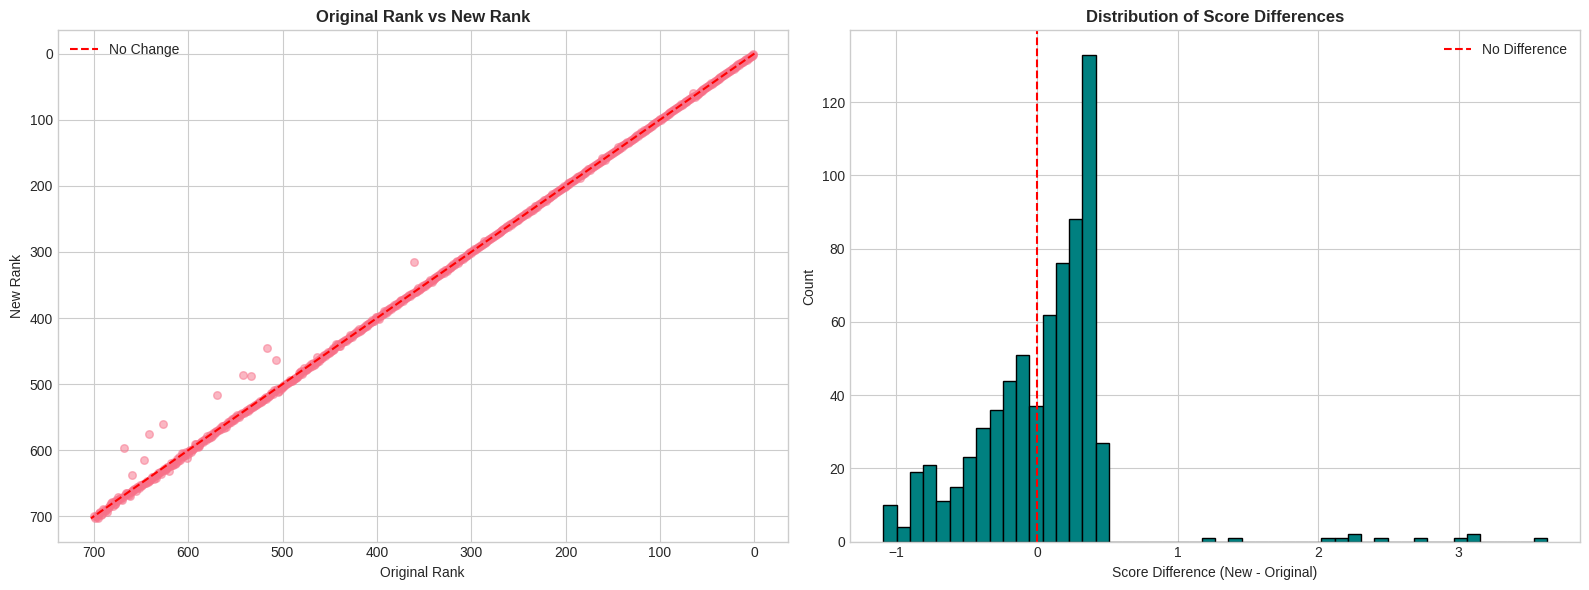

In [12]:
# ============================================================
#PHASE 3.9 - ORIGINAL VS NEW COMPARISON ANALYSIS
# ============================================================

import re

# --- Defensive: ensure overall_score_clean exists ---
# If Cell 6 was skipped or kernel restarted, recreate it here
if 'overall_score_clean' not in df.columns:
    def clean_score(val):
        if pd.isna(val) or val == '-' or val == '':
            return np.nan
        val_str = str(val).strip()
        if re.search(r'\d+[+=]', val_str):
            return np.nan
        try:
            return float(val_str)
        except ValueError:
            return np.nan
    df['overall_score_clean'] = df['Overall SCORE'].apply(clean_score)
    print("⚠️  'overall_score_clean' was missing — recreated from 'Overall SCORE'")

# Create comparison dataframe
comparison_df = df[['sl', 'name', 'country', 'status', 'size',
                     'Overall SCORE', 'overall_score_new',
                     'overall_rank_new']].copy()

valid_original = df[df['overall_score_clean'].notna()].copy()
valid_original['overall_rank_original'] = valid_original['sl']

# Merge original rank back
comparison_df = comparison_df.merge(
    valid_original[['name', 'overall_rank_original']],
    on='name',
    how='left'
)

# Calculate rank change (negative = improved, positive = dropped)
comparison_df['rank_change'] = comparison_df['overall_rank_new'] - comparison_df['overall_rank_original']

# Score difference — only where original score exists
comparison_df['score_difference'] = comparison_df['overall_score_new'] - df['overall_score_clean']

print("=== ORIGINAL VS NEW COMPARISON ===")
print(f"Universities with valid original scores: {valid_original.shape[0]}")
print(f"Universities with only new scores: {df.shape[0] - valid_original.shape[0]}")

print("\n--- TOP 10 IMPROVED (New rank better than Original) ---")
improved = comparison_df[comparison_df['rank_change'] < 0].nsmallest(10, 'rank_change')
if len(improved) > 0:
    print(improved[['name', 'overall_rank_original', 'overall_rank_new', 'rank_change']].to_string(index=False))
else:
    print("No universities improved in ranking.")

print("\n--- TOP 10 DROPPED (New rank worse than Original) ---")
dropped = comparison_df[comparison_df['rank_change'] > 0].nlargest(10, 'rank_change')
if len(dropped) > 0:
    print(dropped[['name', 'overall_rank_original', 'overall_rank_new', 'rank_change']].to_string(index=False))
else:
    print("No universities dropped in ranking.")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rank change scatter
ax1 = axes[0]
valid_comp = comparison_df[comparison_df['overall_rank_original'].notna()]
if len(valid_comp) > 0:
    ax1.scatter(valid_comp['overall_rank_original'], valid_comp['overall_rank_new'], alpha=0.5, s=30)
    max_rank = max(valid_comp['overall_rank_original'].max(), valid_comp['overall_rank_new'].max())
    ax1.plot([0, max_rank], [0, max_rank], 'r--', label='No Change')
    ax1.set_xlabel('Original Rank')
    ax1.set_ylabel('New Rank')
    ax1.set_title('Original Rank vs New Rank', fontweight='bold')
    ax1.legend()
    ax1.invert_xaxis()
    ax1.invert_yaxis()
else:
    ax1.text(0.5, 0.5, 'No valid original ranks', ha='center', va='center', transform=ax1.transAxes)

# Score difference distribution
ax2 = axes[1]
valid_diff = comparison_df['score_difference'].dropna()
if len(valid_diff) > 0:
    valid_diff.hist(bins=50, ax=ax2, color='teal', edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', label='No Difference')
    ax2.set_xlabel('Score Difference (New - Original)')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of Score Differences', fontweight='bold')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'No valid score differences', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig('original_vs_new_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


##isualization

In [13]:
# ============================================================
#  PHASE 4 - ADVANCED ANALYSIS
# ============================================================

# 4.1 Country-level aggregation
country_stats = df.groupby('country').agg({
    'overall_score_new': ['mean', 'median', 'std', 'count'],
    'overall_rank_new': 'min',
    'AR score_imputed': 'mean',
    'ER score_imputed': 'mean',
    'CPF score_imputed': 'mean'
}).round(2)
country_stats.columns = ['_'.join(col).strip() for col in country_stats.columns]
country_stats = country_stats.reset_index()
country_stats = country_stats.sort_values('overall_score_new_mean', ascending=False)

print("=== TOP 15 COUNTRIES BY AVERAGE OVERALL SCORE ===")
print(country_stats.head(15)[['country', 'overall_score_new_mean', 'overall_score_new_median', 'overall_rank_new_min']].to_string(index=False))

# 4.2 Status comparison
status_stats = df.groupby('status').agg({
    'overall_score_new': ['mean', 'std'],
    'overall_rank_new': 'min'
}).round(2)
print("\n=== SCORE BY STATUS ===")
print(status_stats)

# 4.3 Size comparison
size_stats = df.groupby('size').agg({
    'overall_score_new': ['mean', 'std'],
    'overall_rank_new': 'min'
}).round(2)
print("\n=== SCORE BY SIZE ===")
print(size_stats)

# 4.4 Statistical tests
from scipy.stats import f_oneway, ttest_ind

# ANOVA: Overall score across sizes
size_groups = [group['overall_score_new'].values for name, group in df.groupby('size') if pd.notna(name)]
f_stat, p_value = f_oneway(*size_groups)
print(f"\n=== ANOVA: Overall Score by Size ===")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

# BUG FIX: the old check `'Private' in df['status'].values` never matched,
# since the actual categories are 'Private not for Profit' / 'Private for Profit'
# (no category is literally just 'Private') -- so this test silently never ran.
df['status_group'] = np.where(df['status'] == 'Public', 'Public', 'Private')

public_scores = df[df['status_group'] == 'Public']['overall_score_new']
private_scores = df[df['status_group'] == 'Private']['overall_score_new']
t_stat, p_val = ttest_ind(public_scores, private_scores, equal_var=False)
print(f"\n=== T-TEST: Public vs Private (Private = both for-profit and not-for-profit) ===")
print(f"n_public={len(public_scores)}, n_private={len(private_scores)}")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")



=== TOP 15 COUNTRIES BY AVERAGE OVERALL SCORE ===
             country  overall_score_new_mean  overall_score_new_median  overall_rank_new_min
           Singapore                   68.55                     70.88                    10
               Qatar                   60.51                     60.51                   110
         Netherlands                   60.14                     60.77                    48
Hong Kong SAR, China                   59.28                     67.65                    11
              Sweden                   53.88                     57.94                    71
         Switzerland                   52.81                     56.42                     9
             Denmark                   51.92                     55.92                    91
         New Zealand                   51.08                     51.33                    67
           Australia                   49.43                     46.72                    19
             Ireland

In [14]:
# ============================================================
# EXPORT DATA FILES
# ============================================================

# File 1: Complete dataset with all new columns
df.to_csv('qs_rankings_complete.csv', index=False, encoding='utf-8-sig')
print("✅ Exported: qs_rankings_complete.csv")

# File 2: New rankings only (new columns)
new_cols = ['sl', 'name', 'country', 'status', 'size'] + \
           [f"{ind} score_imputed" for ind in INDICATORS] + \
           [f"{ind} score_standardized" for ind in INDICATORS] + \
           [f"{ind}_rank_new" for ind in INDICATORS] + \
           ['overall_score_new', 'overall_rank_new']
df[new_cols].to_csv('qs_rankings_new_only.csv', index=False, encoding='utf-8-sig')
print("✅ Exported: qs_rankings_new_only.csv")

# File 3: Country summary
country_stats.to_csv('country_summary.csv', index=False, encoding='utf-8-sig')
print("✅ Exported: country_summary.csv")

# File 4: Original vs New comparison report
comparison_df.to_csv('comparison_report.csv', index=False, encoding='utf-8-sig')
print("✅ Exported: comparison_report.csv")

# File 5: Missing value analysis report
missing_analysis.to_csv('missing_value_report.csv', encoding='utf-8-sig')
print("✅ Exported: missing_value_report.csv")

print("\n=== ALL FILES EXPORTED SUCCESSFULLY ===")



✅ Exported: qs_rankings_complete.csv
✅ Exported: qs_rankings_new_only.csv
✅ Exported: country_summary.csv
✅ Exported: comparison_report.csv
✅ Exported: missing_value_report.csv

=== ALL FILES EXPORTED SUCCESSFULLY ===


In [15]:

# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 80)
print("QS WORLD UNIVERSITY RANKINGS ANALYSIS - COMPLETE")
print("=" * 80)
print(f"\nDataset: {df.shape[0]} universities across {df['country'].nunique()} countries")
print(f"Original columns preserved: {len(df_original.columns)}")
print(f"New columns added: {len(df.columns) - len(df_original.columns)}")

print(f"\n--- NEW COLUMNS CREATED ---")
print("Score columns (imputed):")
for ind in INDICATORS:
    print(f"  - {ind} score_imputed")
print("\nRank columns (dense ranking):")
for ind in INDICATORS:
    print(f"  - {ind}_rank_new")
print("  - overall_rank_new")
print("\nOverall score:")
print("  - overall_score_new")

print(f"\n--- RANKING SUMMARY (NEW) ---")
print(f"Top university: {df.loc[df['overall_rank_new'].idxmin(), 'name']} ({df.loc[df['overall_rank_new'].idxmin(), 'country']})")
print(f"Score range: {df['overall_score_new'].min():.2f} - {df['overall_score_new'].max():.2f}")

print(f"\n--- MISSING VALUES ---")
print(f"All score values imputed: {'✅ YES' if df[[f'{ind} score_imputed' for ind in INDICATORS]].isna().sum().sum() == 0 else '❌ NO'}")
print(f"Overall score calculated: {'✅ YES' if df['overall_score_new'].isna().sum() == 0 else '❌ NO'}")
print(f"Status/size filled: {'✅ YES' if len(df[(df['status'].isna()) | (df['size'].isna())]) == 0 else '❌ NO'}")

print(f"\n--- EXPORTED FILES ---")
print("  1. qs_rankings_complete.csv - Full dataset with all columns")
print("  2. qs_rankings_new_only.csv - New calculated columns only")
print("  3. country_summary.csv - Country-level statistics")
print("  4. comparison_report.csv - Original vs New comparison")
print("  5. missing_value_report.csv - Missing value analysis")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)

QS WORLD UNIVERSITY RANKINGS ANALYSIS - COMPLETE

Dataset: 1504 universities across 106 countries
Original columns preserved: 27
New columns added: 52

--- NEW COLUMNS CREATED ---
Score columns (imputed):
  - AR score_imputed
  - ER score_imputed
  - FSR score_imputed
  - CPF score_imputed
  - IFR score_imputed
  - ISR score_imputed
  - IRN score_imputed
  - EO score_imputed
  - SUS score_imputed

Rank columns (dense ranking):
  - AR_rank_new
  - ER_rank_new
  - FSR_rank_new
  - CPF_rank_new
  - IFR_rank_new
  - ISR_rank_new
  - IRN_rank_new
  - EO_rank_new
  - SUS_rank_new
  - overall_rank_new

Overall score:
  - overall_score_new

--- RANKING SUMMARY (NEW) ---
Top university: Massachusetts Institute of Technology (MIT) (United States of America)
Score range: 9.69 - 98.92

--- MISSING VALUES ---
All score values imputed: ✅ YES
Overall score calculated: ✅ YES
Status/size filled: ✅ YES

--- EXPORTED FILES ---
  1. qs_rankings_complete.csv - Full dataset with all columns
  2. qs_rankings